# Attestation timings within committee - missed slots

#### Maria Silva, July 2025


## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))

In [3]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

## 2. Load data

#### Attestations

In [4]:
missed_atts_file = os.path.join(repo_dir, "data", "missed_12243620_12294020", "sample_atts.parquet")
atts_df = pd.read_parquet(missed_atts_file)
atts_df["atts_prop_time_ms"] = atts_df["atts_arrival_time_ms"]-4000
atts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2595284 entries, 0 to 2595283
Data columns (total 7 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   slot                  int64 
 1   node_name             object
 2   node_country          object
 3   atts_validator        int64 
 4   atts_subnet           object
 5   atts_arrival_time_ms  int64 
 6   atts_prop_time_ms     int64 
dtypes: int64(4), object(3)
memory usage: 138.6+ MB


#### Validator info

In [5]:
val_file = os.path.join(repo_dir, "data", "ethseer_val_info.parquet")
val_df = pd.read_parquet(val_file)
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2031272 entries, 0 to 2031271
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   index   int64 
 1   entity  object
dtypes: int64(1), object(1)
memory usage: 31.0+ MB


#### Join data and process

In [6]:
# Join
df = (
    atts_df.merge(val_df, right_on="index", left_on="atts_validator", how="left")
    .drop(columns=["index"])
    .fillna({"entity": "unknown"})
)
# Group low cardinality entities into "other" category
entity_counts = df["entity"].value_counts()/len(df)
df = df.merge(entity_counts, left_on="entity", right_index=True)
df["entity"] = np.where(df["count"]>0.01, df["entity"], "other")
# Print info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2595284 entries, 0 to 2595283
Data columns (total 9 columns):
 #   Column                Dtype  
---  ------                -----  
 0   slot                  int64  
 1   node_name             object 
 2   node_country          object 
 3   atts_validator        int64  
 4   atts_subnet           object 
 5   atts_arrival_time_ms  int64  
 6   atts_prop_time_ms     int64  
 7   entity                object 
 8   count                 float64
dtypes: float64(1), int64(4), object(4)
memory usage: 178.2+ MB


In [7]:
df["slot"].nunique()

207

In [8]:
df["node_name"].sort_values().unique()

array(['ethpandaops/mainnet/xatu-tysm-ams3-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-ams3-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-ams3-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-005-subnets-0-1'],
      dtype=object)

## 3. Overall distribution

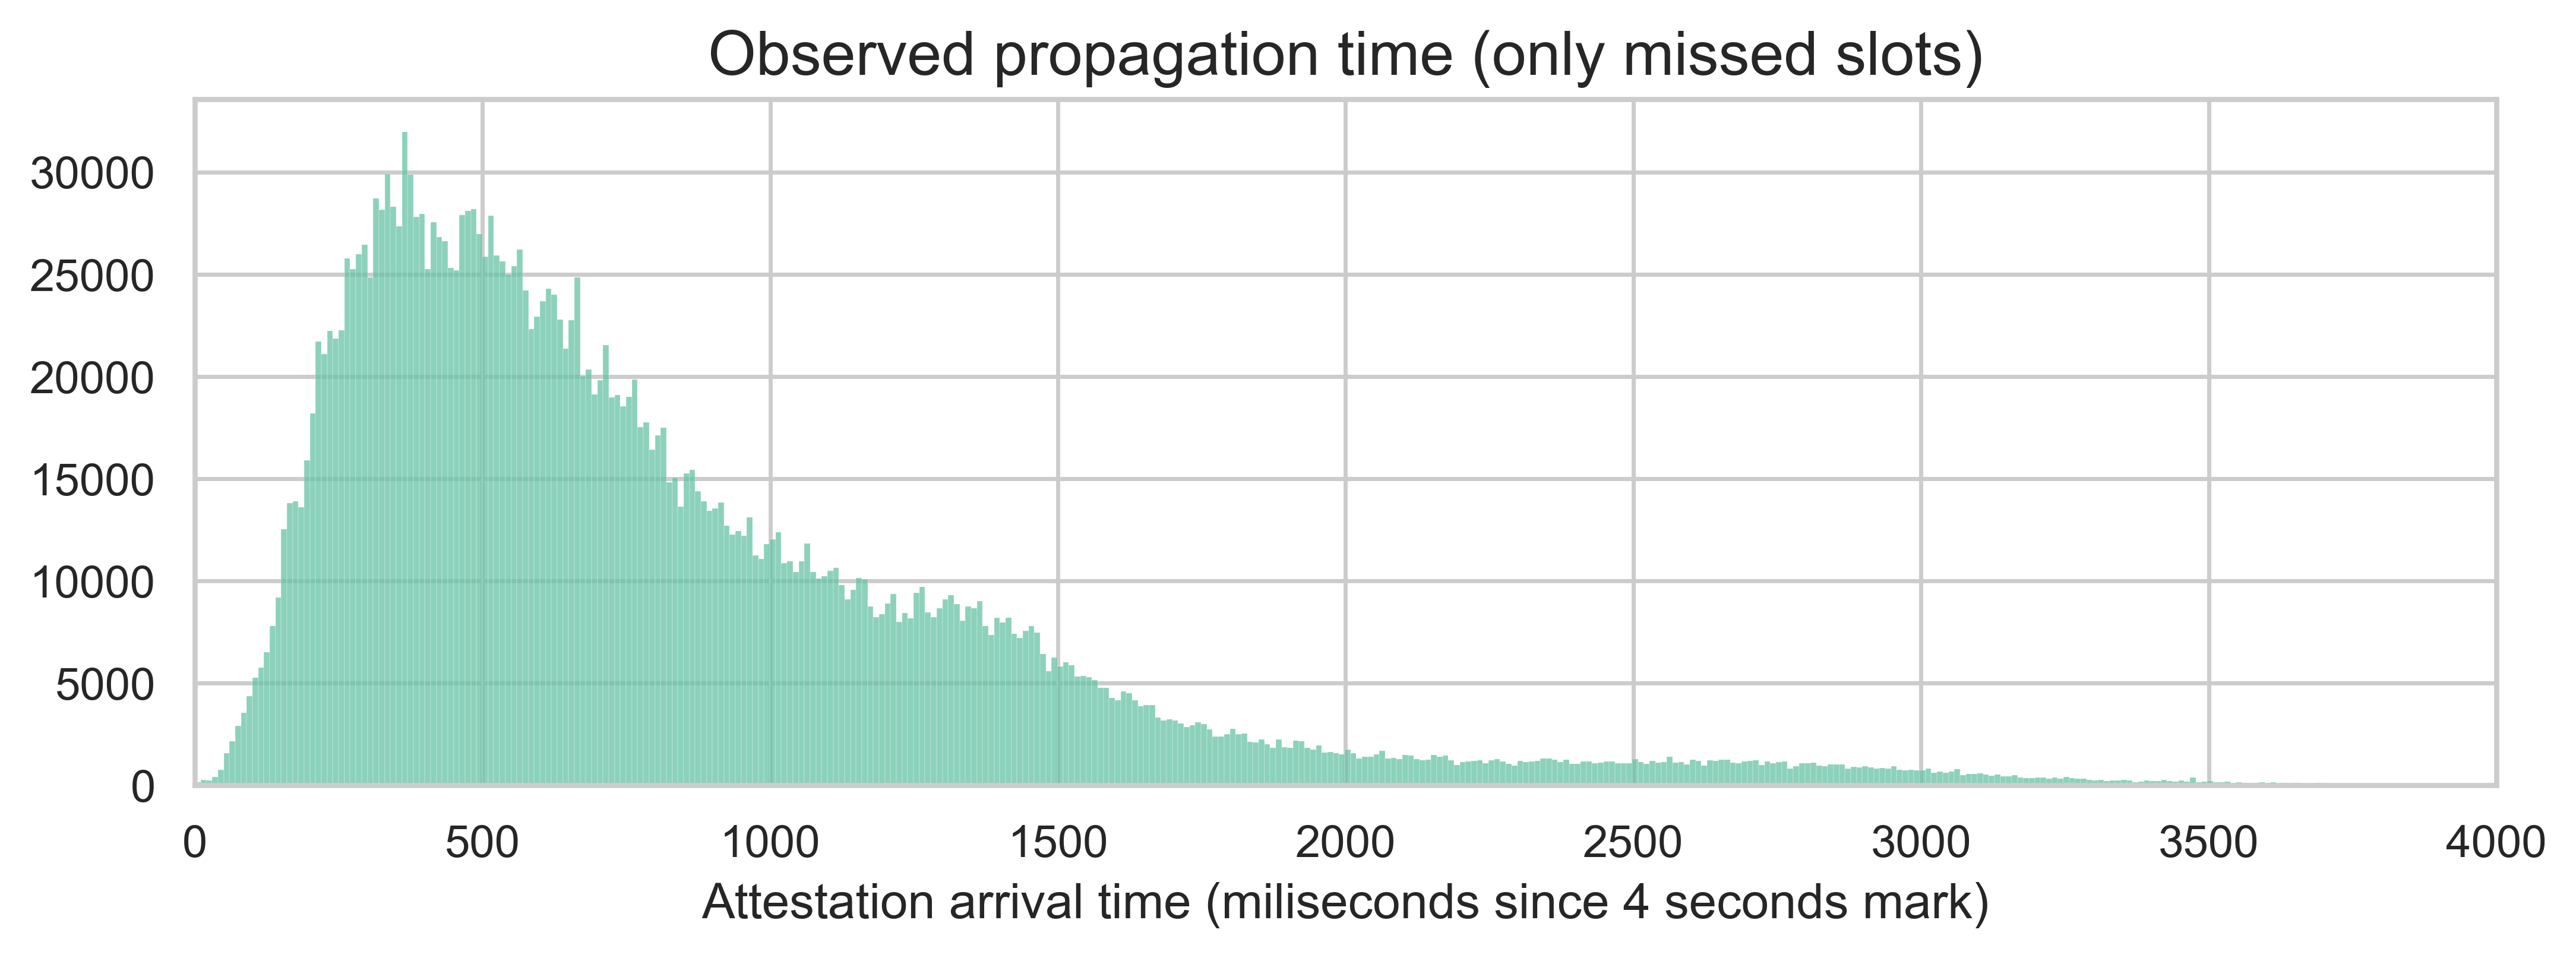

In [9]:
plt.figure(figsize=(10, 3))
sns.histplot(data=df, x="atts_prop_time_ms")
plt.xlim(0, 4000)
plt.title("Observed propagation time (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [10]:
df["atts_prop_time_ms"].agg(["mean", "std"])

mean    831.037780
std     609.822231
Name: atts_prop_time_ms, dtype: float64

In [11]:
df["atts_prop_time_ms"].quantile([0.25, 0.5, 0.66, 0.75, 0.95, 0.99])

0.25     403.0
0.50     660.0
0.66     894.0
0.75    1090.0
0.95    2066.0
0.99    2987.0
Name: atts_prop_time_ms, dtype: float64

#### Per beacon node

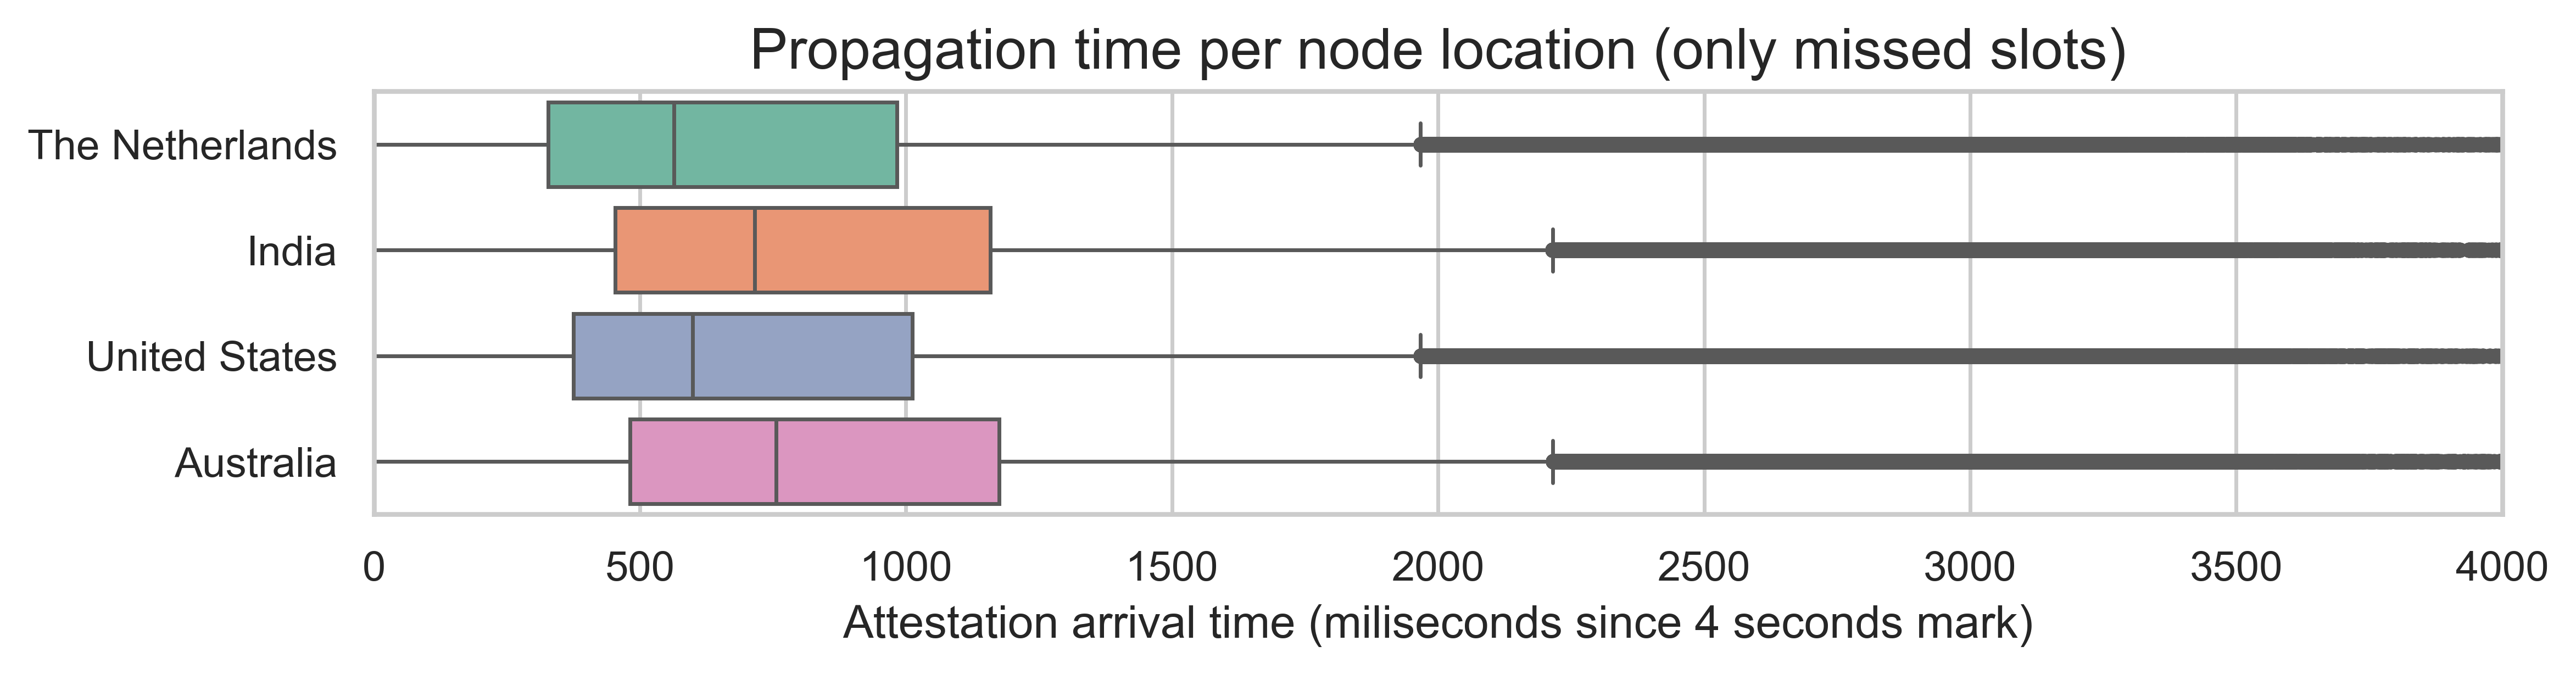

In [12]:
plt.figure(figsize=(10, 2))
sns.boxplot(
    data=df.sort_values("node_name"),
    x="atts_prop_time_ms",
    y="node_country",
    hue="node_country",
    legend=False,
    fliersize=3
)
plt.xlim(0,4000)
plt.title("Propagation time per node location (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [13]:
df.groupby("node_country")["atts_prop_time_ms"].quantile(0.66)

node_country
Australia          991.0
India              957.0
The Netherlands    784.0
United States      811.0
Name: atts_prop_time_ms, dtype: float64

In [14]:
df.groupby("node_country")["atts_prop_time_ms"].quantile(0.95)

node_country
Australia          2171.0
India              2146.0
The Netherlands    1850.0
United States      2028.0
Name: atts_prop_time_ms, dtype: float64

#### Per attester entity

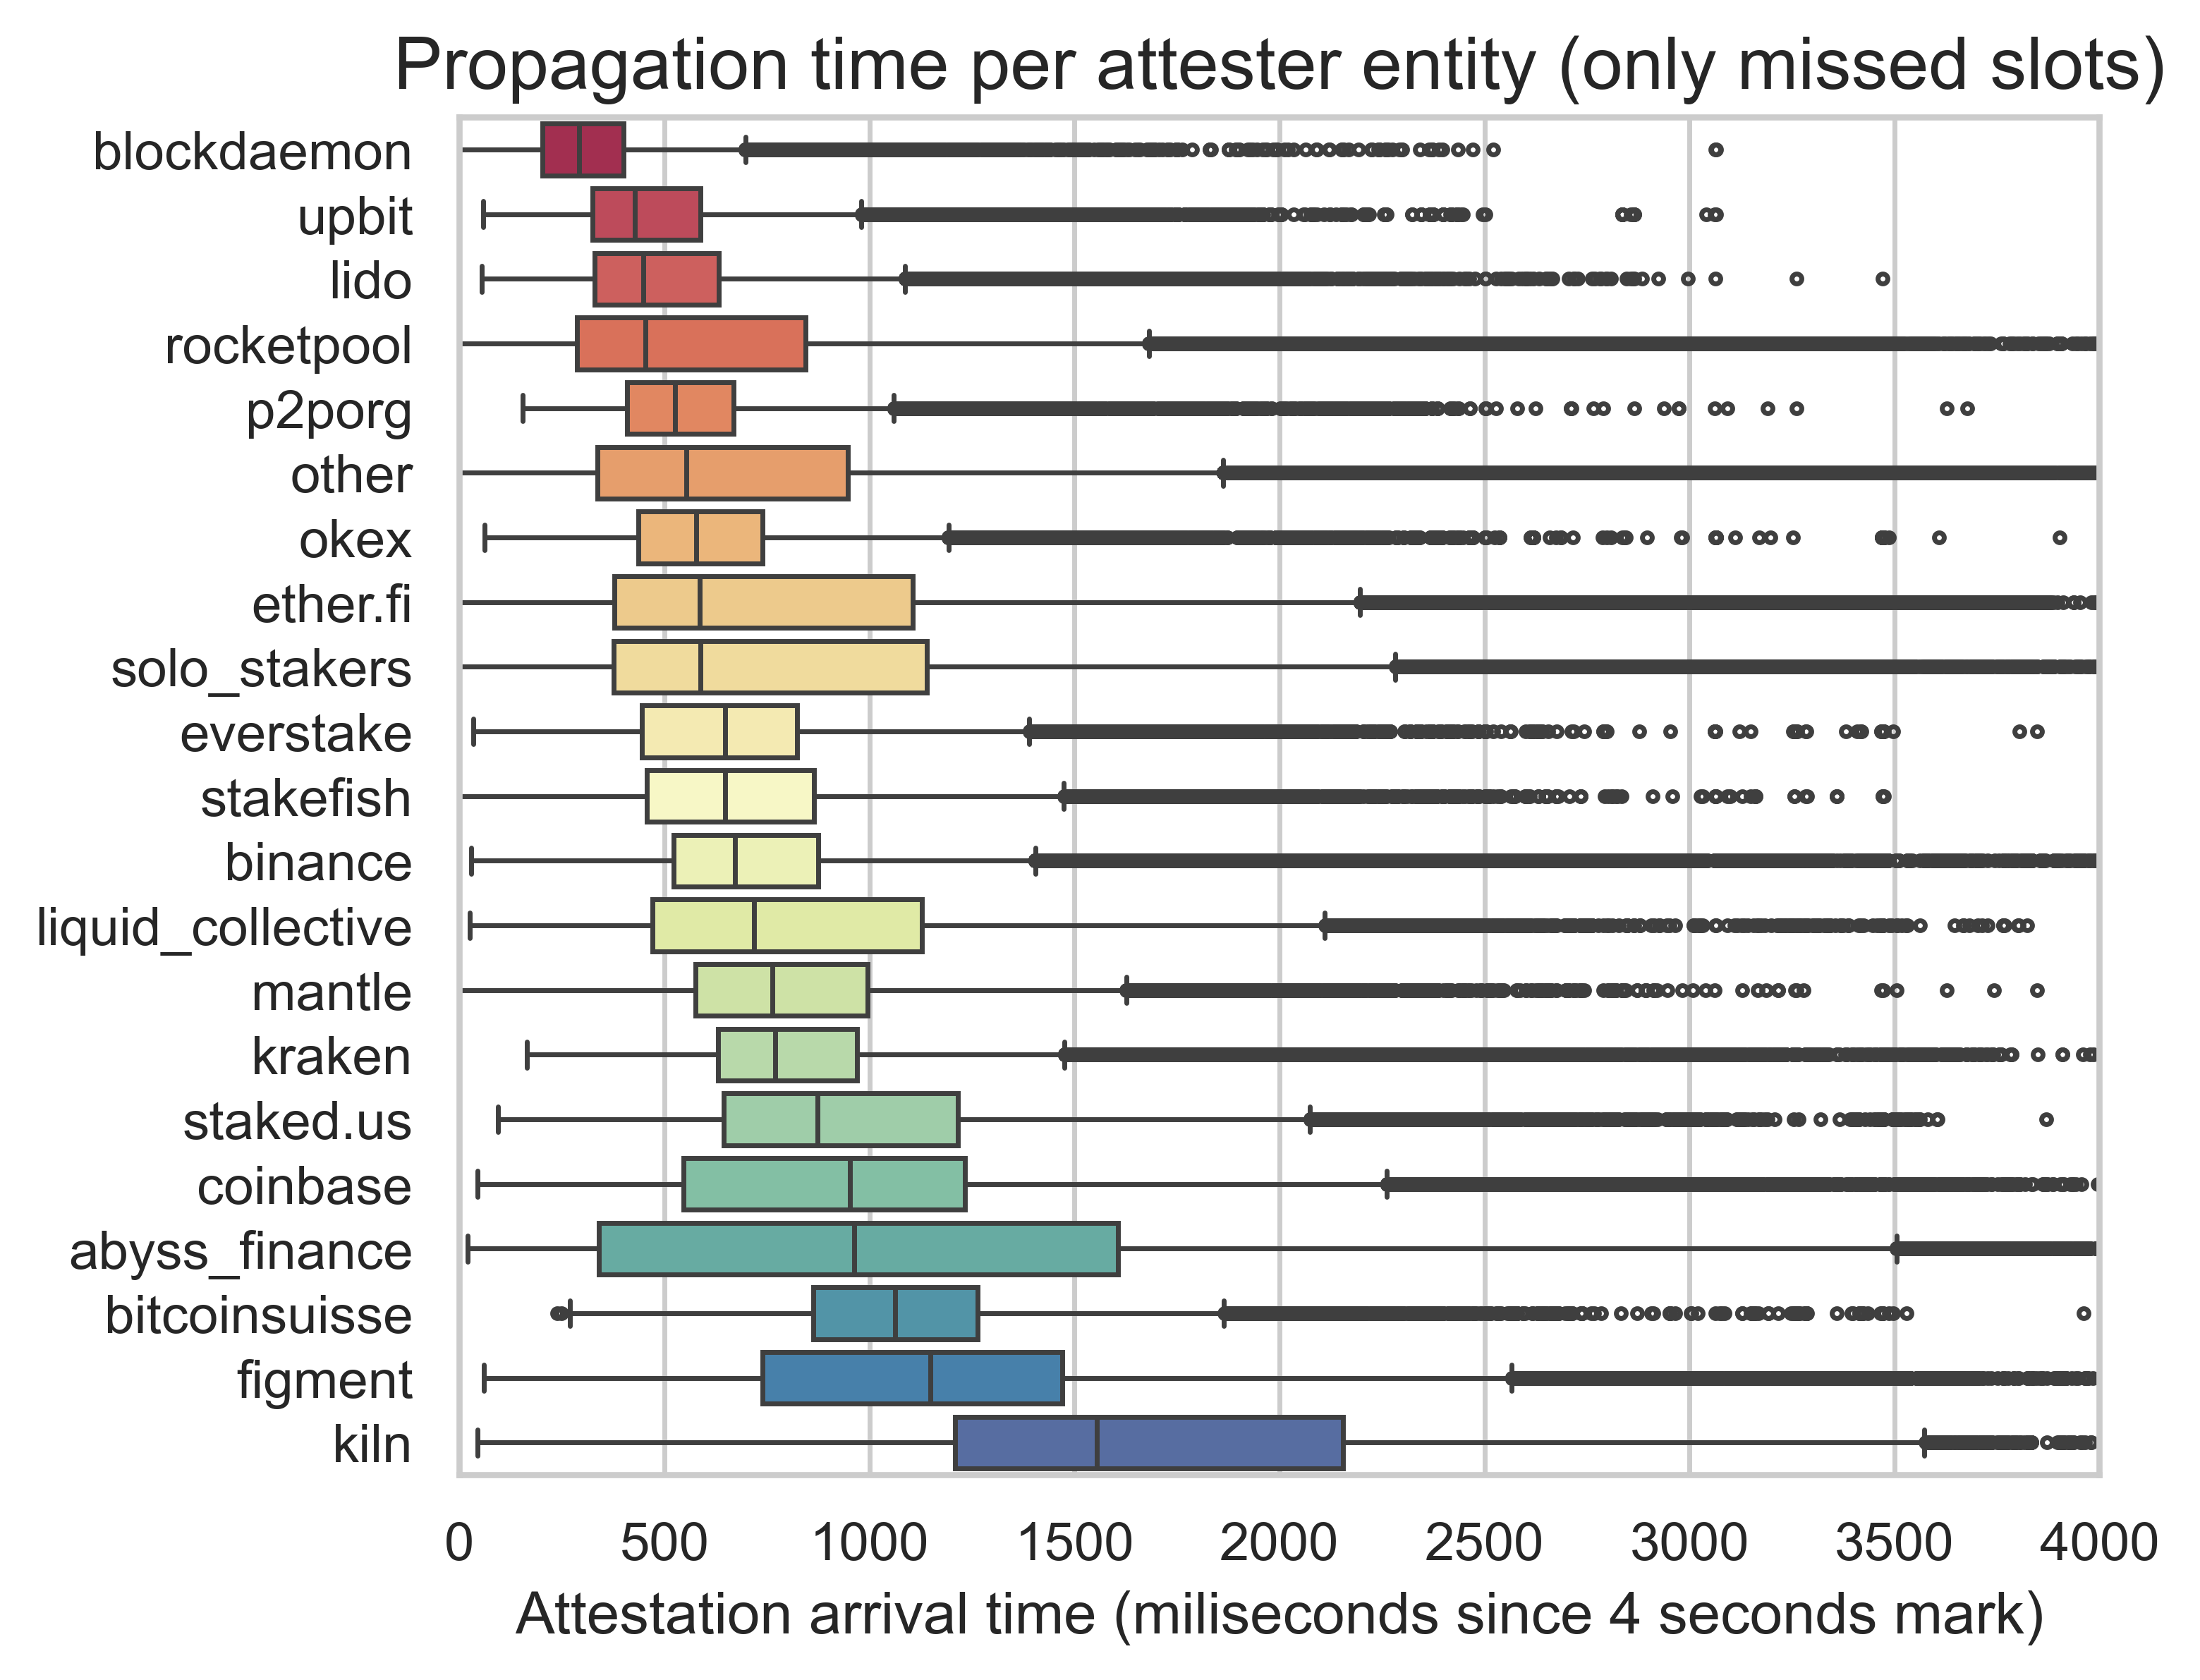

In [15]:
median_df = (
    df.groupby("entity")["atts_prop_time_ms"]
    .median()
    .reset_index()
    .rename(columns={"atts_prop_time_ms": "median"})
)
temp_df = df.merge(median_df, on="entity", how="left").sort_values("median")

plt.figure(figsize=(6, 5))
sns.boxplot(
    data=temp_df,
    x="atts_prop_time_ms",
    y="entity",
    hue="entity",
    legend=False,
    palette="Spectral",
    fliersize=2
)
plt.xlim(0,4000)
plt.title("Propagation time per attester entity (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

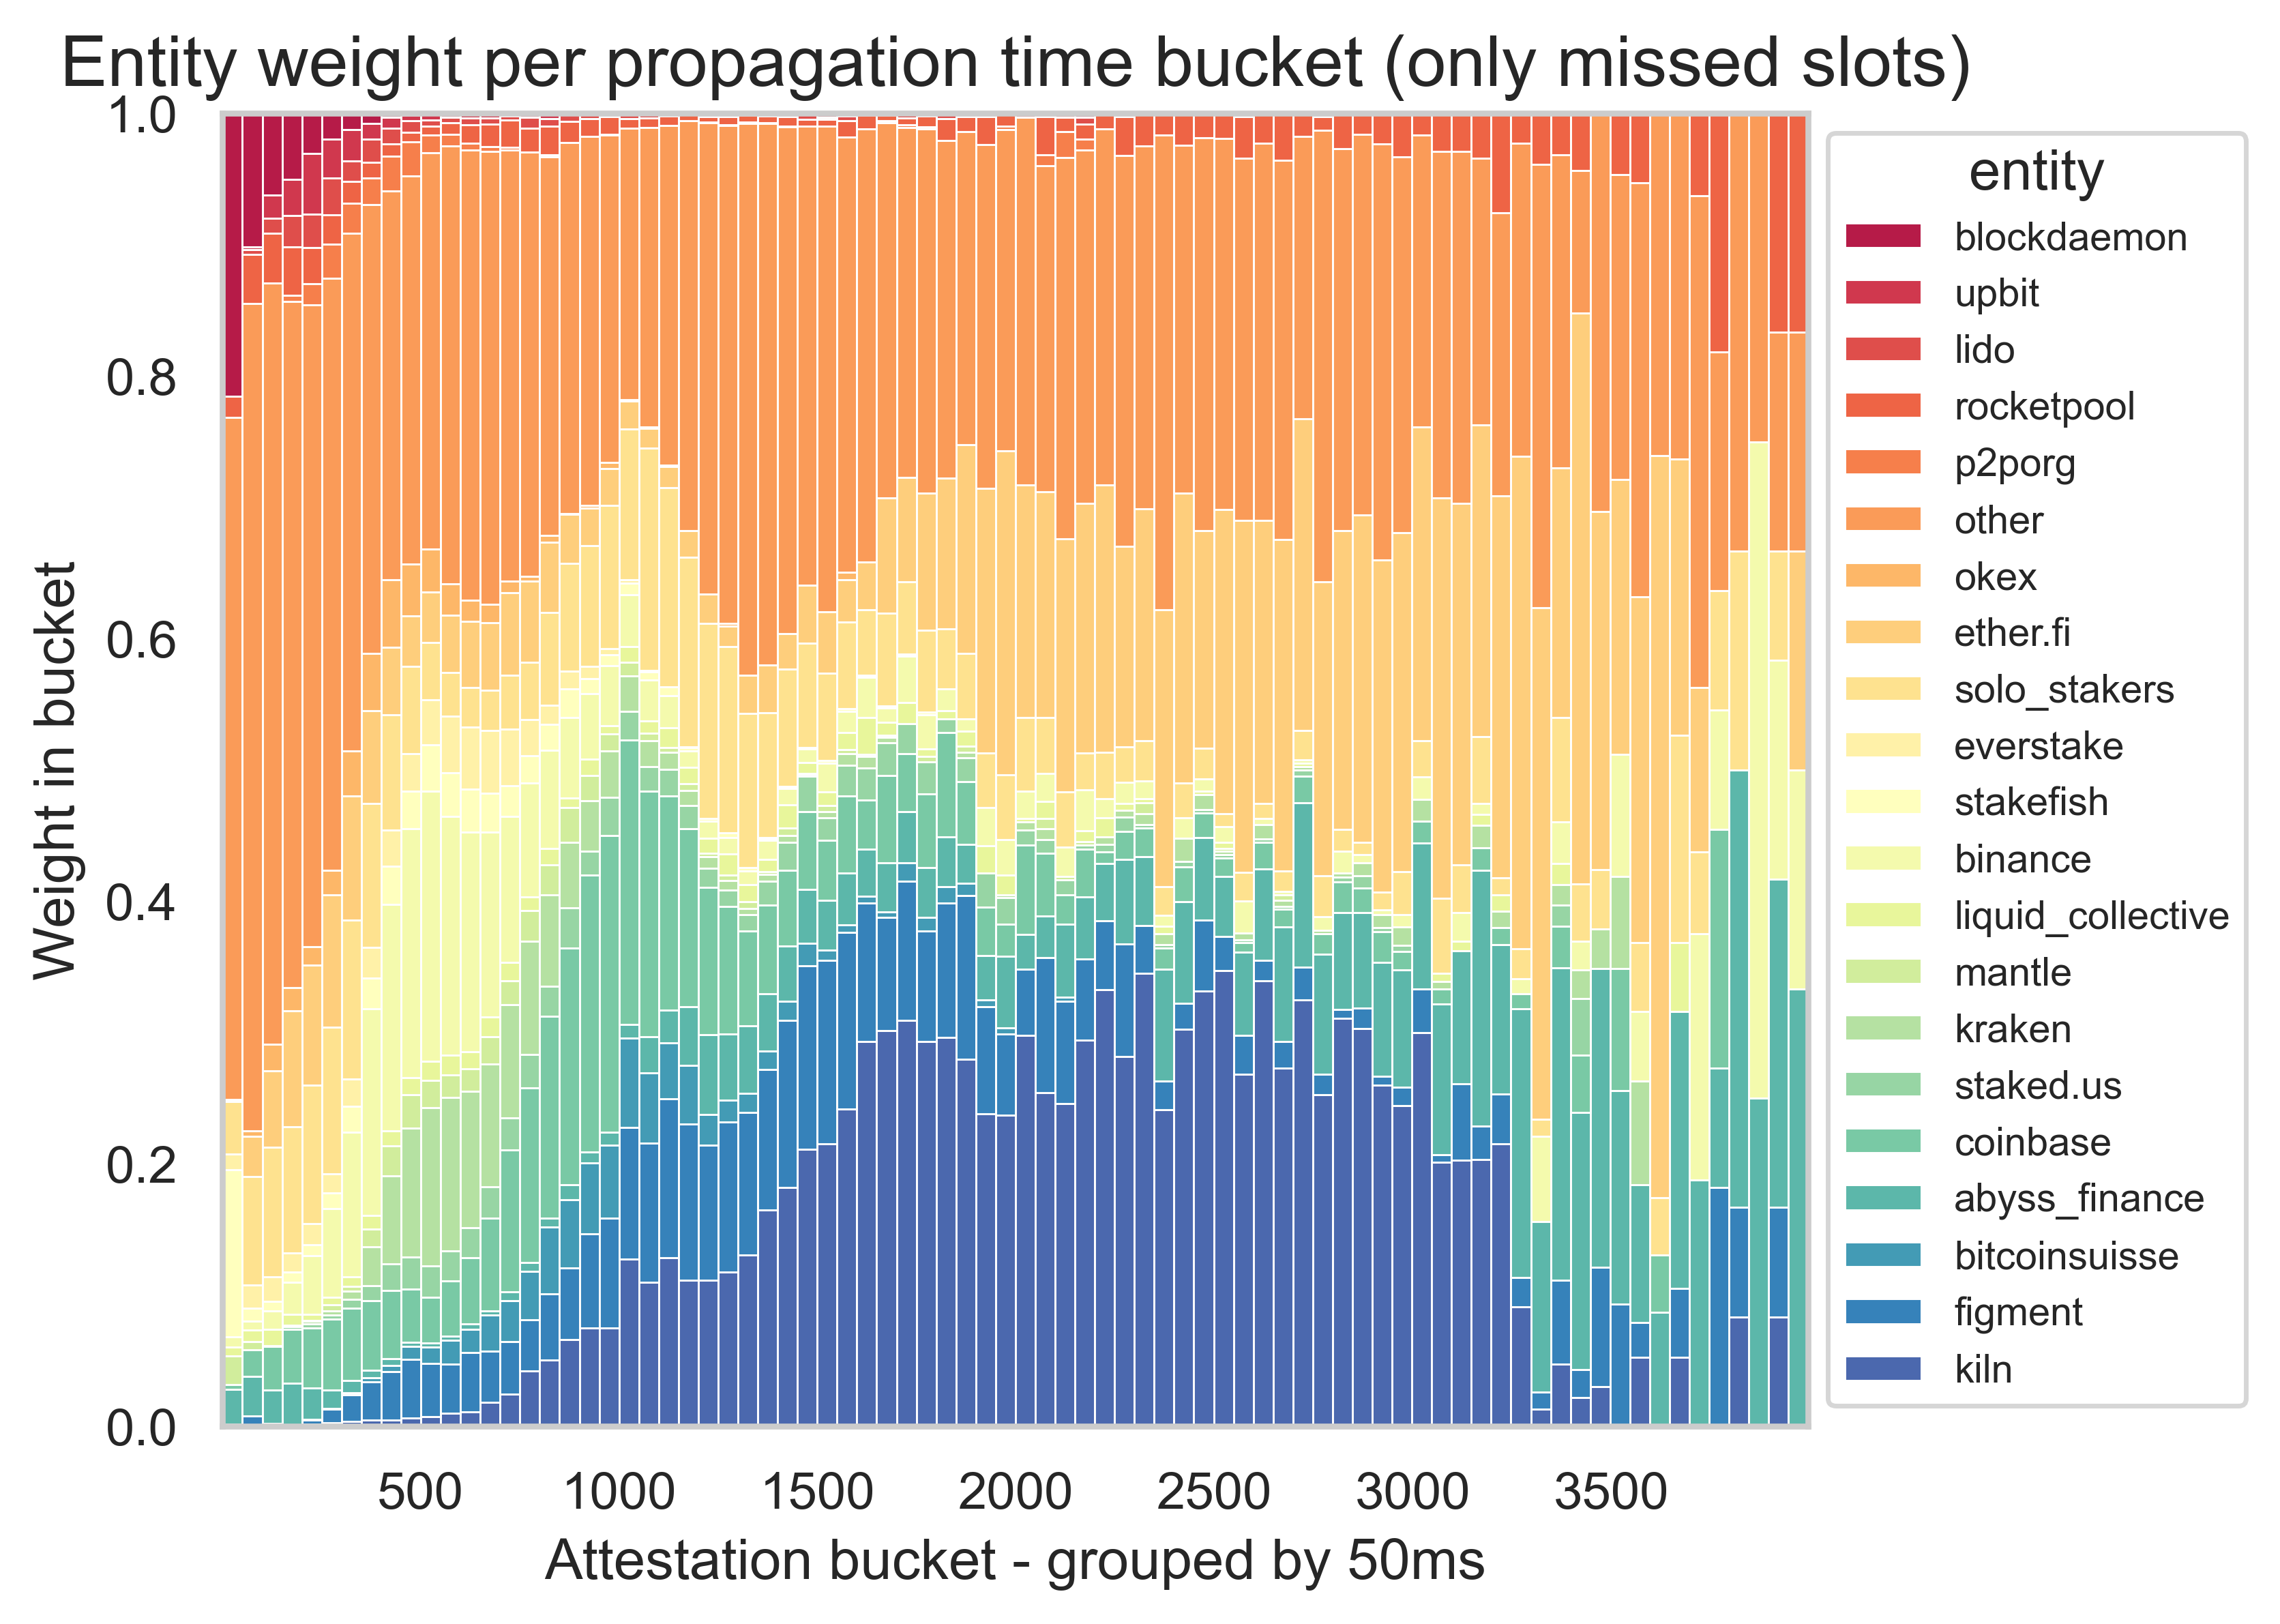

In [16]:
temp_df = (
    df[df["atts_prop_time_ms"] > 0]
    .groupby(["slot", "atts_subnet", "atts_validator", "entity"])["atts_prop_time_ms"]
    .min()
    .reset_index()
    .merge(median_df, on="entity", how="left")
    .sort_values("median")
)
temp_df = temp_df[temp_df["atts_prop_time_ms"].between(0,4000)]
plt.figure(figsize=(6, 5))
ax = sns.histplot(
    data=temp_df,
    x="atts_prop_time_ms",
    hue="entity",
    multiple="fill",
    palette="Spectral",
    alpha=1,
    bins=80
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize='x-small')
plt.title("Entity weight per propagation time bucket (only missed slots)")
plt.ylabel("Weight in bucket")
plt.xlabel("Attestation bucket - grouped by 50ms")
plt.show()

## 4. Distribution on subnet

In [17]:
agg_df = (
    df[df["atts_prop_time_ms"] > 0]
    .groupby(["slot", "atts_subnet", "atts_validator", "entity"])["atts_prop_time_ms"]
    .min()
    .reset_index()
    .groupby(["slot", "atts_subnet"])["atts_prop_time_ms"]
    .quantile([0.66, 0.95])
    .reset_index()
    .rename(columns={"level_2": "Percentile"})
)

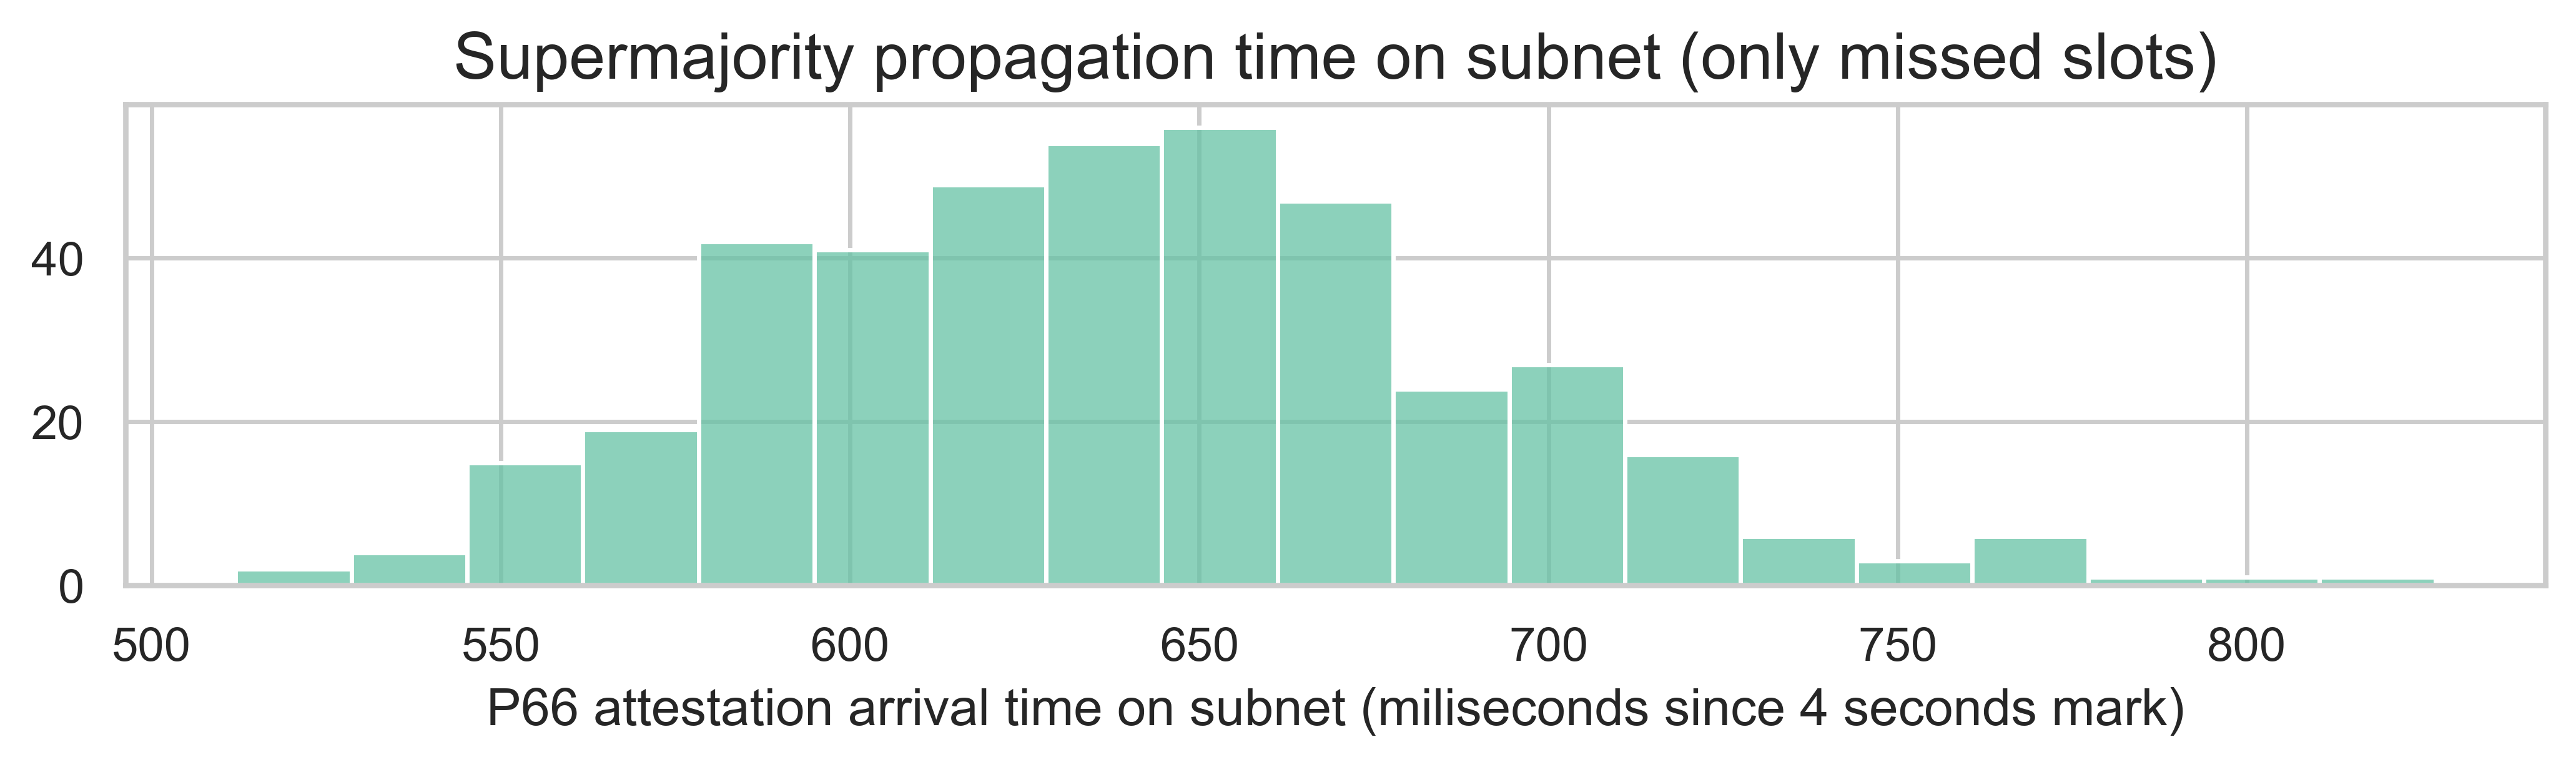

In [18]:
plt.figure(figsize=(10, 2))
sns.histplot(data=agg_df[agg_df["Percentile"]==0.66], x="atts_prop_time_ms")
plt.title("Supermajority propagation time on subnet (only missed slots)")
plt.ylabel("")
plt.xlabel("P66 attestation arrival time on subnet (miliseconds since 4 seconds mark)")
plt.show()

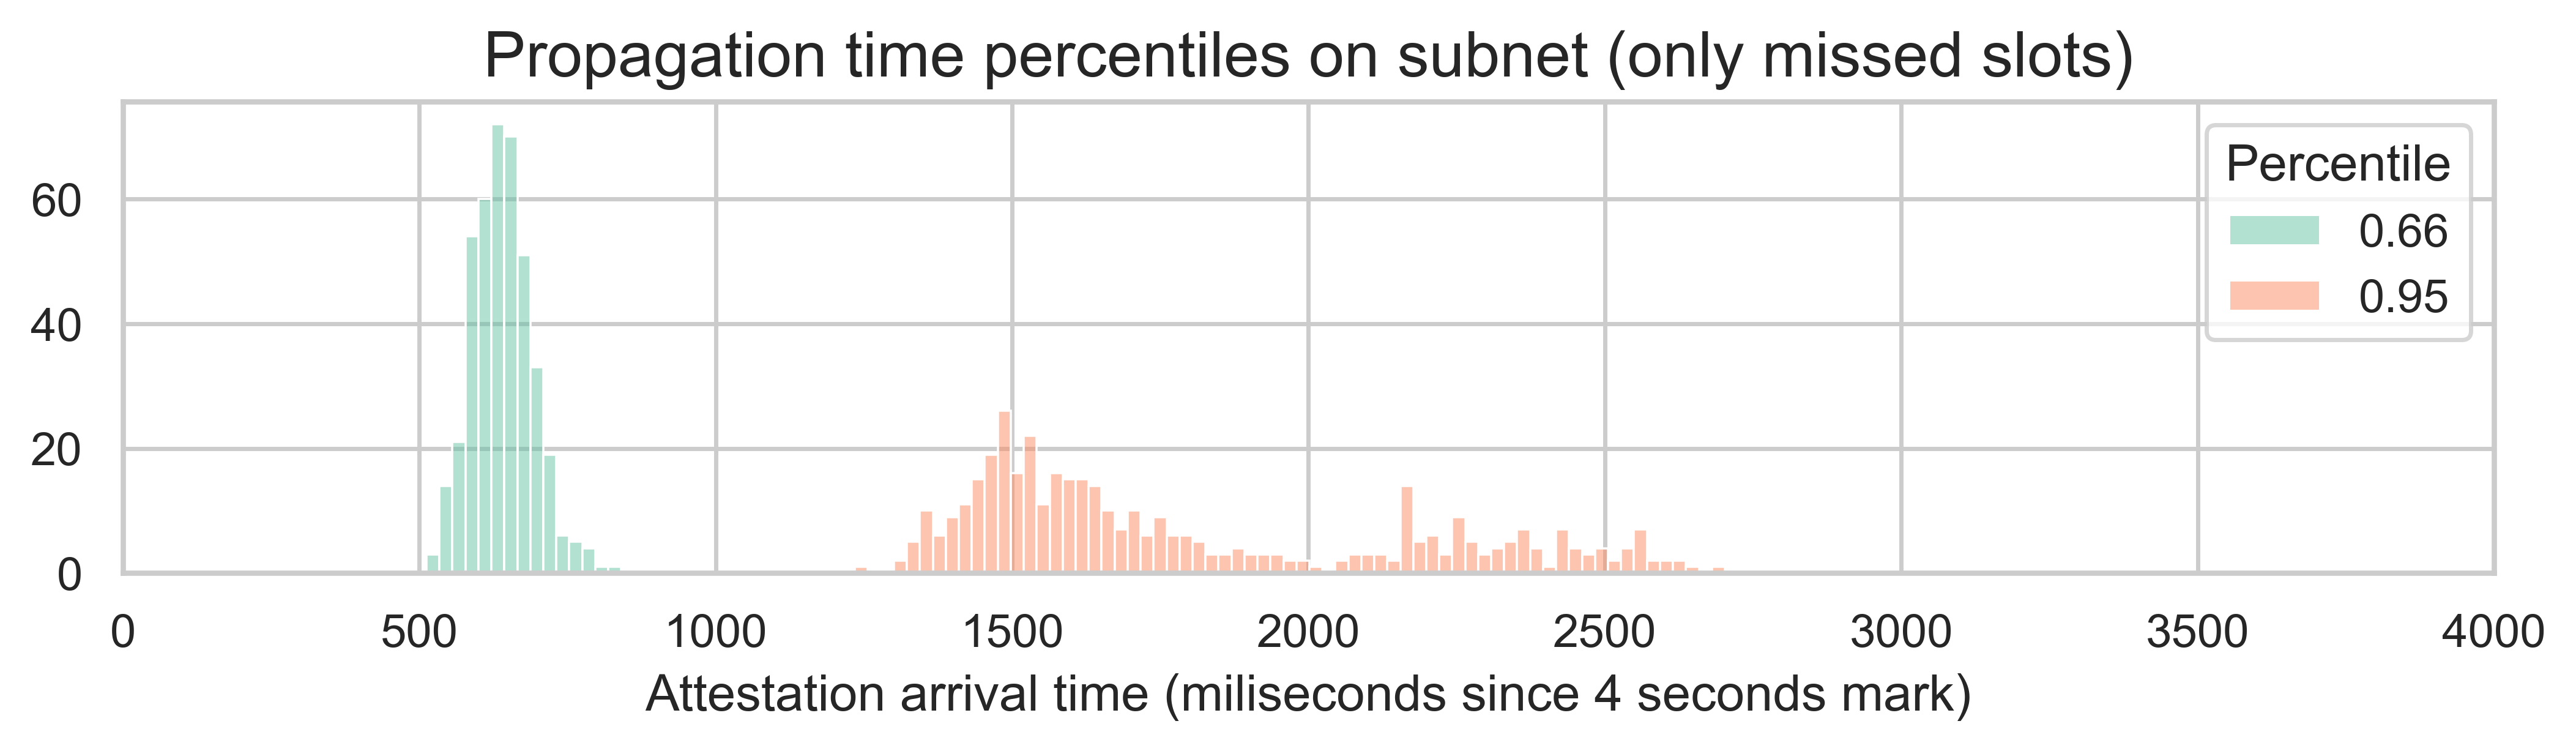

In [19]:
plt.figure(figsize=(10, 2))
sns.histplot(data=agg_df, x="atts_prop_time_ms", hue="Percentile", palette="Set2", bins=100)
plt.xlim(0, 4000)
plt.title("Propagation time percentiles on subnet (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [20]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].quantile(0.95)

Percentile
0.66     722.238
0.95    2504.950
Name: atts_prop_time_ms, dtype: float64

In [21]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].max()

Percentile
0.66     827.0
0.95    2702.5
Name: atts_prop_time_ms, dtype: float64

In [22]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].mean()

Percentile
0.66     640.140821
0.95    1793.867391
Name: atts_prop_time_ms, dtype: float64